# Part E – Tree-Based Classification Models

Tasks Covered:

16. Implement **Decision Tree Classifier**  
17. Analyze **overfitting** by comparing training and testing performance  
18. Implement **Random Forest Classifier**  
19. Compare **Decision Tree vs Random Forest** in terms of **accuracy and generalization**


## 1) Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)


In [2]:
df = pd.read_csv('Risk_Alert_Classifier_Dataset_4600 - Risk_Alert_Classifier_Dataset_4600.csv.csv')
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (4600, 19)


,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0


## 2) Data Preparation

- Convert date columns into year/month/day
- Encode categorical columns
- Split data into train and test sets using stratification
- Apply KNN Imputer


In [3]:
date_cols = [c for c in df.columns if 'date' in c.lower()]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    df[col + '_year'] = df[col].dt.year
    df[col + '_month'] = df[col].dt.month
    df[col + '_day'] = df[col].dt.day
    df.drop(columns=[col], inplace=True)

df_encoded = df.copy()

categorical_cols = df_encoded.select_dtypes(include='object').columns
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    encoders[col] = le

target = 'risk_status'
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

print("Target Variable:", target)
print("Features Shape:", X.shape)


Target Variable: risk_status
Features Shape: (4600, 20)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

imputer = KNNImputer(n_neighbors=5)

X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

print("Train Shape:", X_train_imputed.shape)
print("Test Shape :", X_test_imputed.shape)
print("\nTrain Class Distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest Class Distribution:")
print(y_test.value_counts(normalize=True))


Train Shape: (3680, 20)
Test Shape : (920, 20)

Train Class Distribution:
risk_status
0    0.878804
1    0.121196
Name: proportion, dtype: float64

Test Class Distribution:
risk_status
0    0.879348
1    0.120652
Name: proportion, dtype: float64


## 3) Helper Function for Model Evaluation

In [5]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name='Model'):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    results = {
        'Model': model_name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Train Precision': precision_score(y_train, y_train_pred, zero_division=0),
        'Test Precision': precision_score(y_test, y_test_pred, zero_division=0),
        'Train Recall': recall_score(y_train, y_train_pred, zero_division=0),
        'Test Recall': recall_score(y_test, y_test_pred, zero_division=0),
        'Train F1': f1_score(y_train, y_train_pred, zero_division=0),
        'Test F1': f1_score(y_test, y_test_pred, zero_division=0),
        'Train AUC': roc_auc_score(y_train, y_train_prob),
        'Test AUC': roc_auc_score(y_test, y_test_prob)
    }

    return results, y_train_pred, y_test_pred


# Task 16 – Decision Tree Classifier

In [6]:
decision_tree = DecisionTreeClassifier(random_state=42)

dt_results, dt_train_pred, dt_test_pred = evaluate_model(
    decision_tree,
    X_train_imputed, y_train,
    X_test_imputed, y_test,
    model_name='Decision Tree'
)

pd.DataFrame([dt_results])


,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train AUC,Test AUC
0,Decision Tree,1.0,0.969565,1.0,0.880734,1.0,0.864865,1.0,0.872727,1.0,0.924398


In [7]:
print("Decision Tree - Classification Report\n")
print(classification_report(y_test, dt_test_pred))


Decision Tree - Classification Report

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       809
           1       0.88      0.86      0.87       111

    accuracy                           0.97       920
   macro avg       0.93      0.92      0.93       920
weighted avg       0.97      0.97      0.97       920



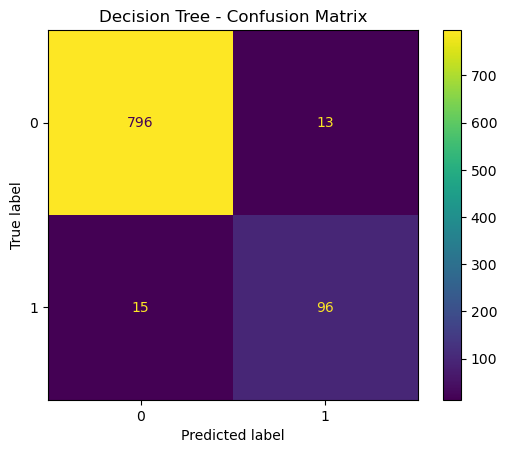

In [8]:
cm_dt = confusion_matrix(y_test, dt_test_pred)
ConfusionMatrixDisplay(confusion_matrix=cm_dt).plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()


# Task 17 – Overfitting Analysis

Compare **training** and **testing** metrics.  
If training performance is much higher than testing performance, the model is likely **overfitting**.


In [9]:
dt_overfit_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC'],
    'Training Score': [
        dt_results['Train Accuracy'],
        dt_results['Train Precision'],
        dt_results['Train Recall'],
        dt_results['Train F1'],
        dt_results['Train AUC']
    ],
    'Testing Score': [
        dt_results['Test Accuracy'],
        dt_results['Test Precision'],
        dt_results['Test Recall'],
        dt_results['Test F1'],
        dt_results['Test AUC']
    ]
})

dt_overfit_df


,Metric,Training Score,Testing Score
0,Accuracy,1.0,0.969565
1,Precision,1.0,0.880734
2,Recall,1.0,0.864865
3,F1,1.0,0.872727
4,AUC,1.0,0.924398


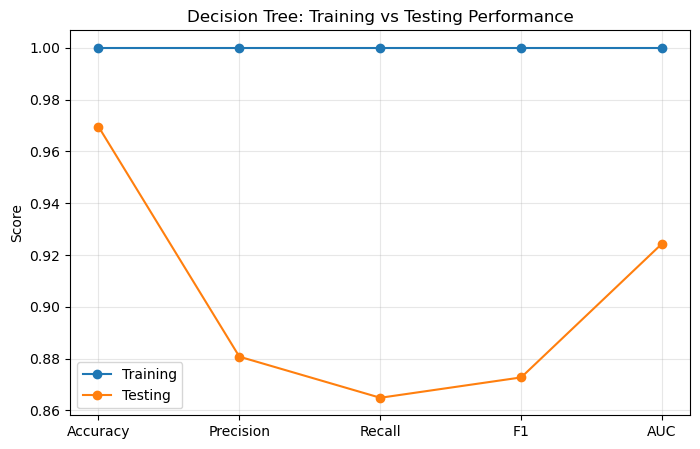

In [10]:
plt.figure(figsize=(8,5))
plt.plot(dt_overfit_df['Metric'], dt_overfit_df['Training Score'], marker='o', label='Training')
plt.plot(dt_overfit_df['Metric'], dt_overfit_df['Testing Score'], marker='o', label='Testing')
plt.title("Decision Tree: Training vs Testing Performance")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Interpretation – Overfitting in Decision Tree

- A very high **training score** and lower **testing score** indicates overfitting.
- Decision Trees can memorize training data if not controlled using pruning or hyperparameter tuning.


# Task 18 – Random Forest Classifier

In [11]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_results, rf_train_pred, rf_test_pred = evaluate_model(
    random_forest,
    X_train_imputed, y_train,
    X_test_imputed, y_test,
    model_name='Random Forest'
)

pd.DataFrame([rf_results])


,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train AUC,Test AUC
0,Random Forest,1.0,0.997826,1.0,1.0,1.0,0.981982,1.0,0.990909,1.0,0.999944


In [12]:
print("Random Forest - Classification Report\n")
print(classification_report(y_test, rf_test_pred))


Random Forest - Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       809
           1       1.00      0.98      0.99       111

    accuracy                           1.00       920
   macro avg       1.00      0.99      0.99       920
weighted avg       1.00      1.00      1.00       920



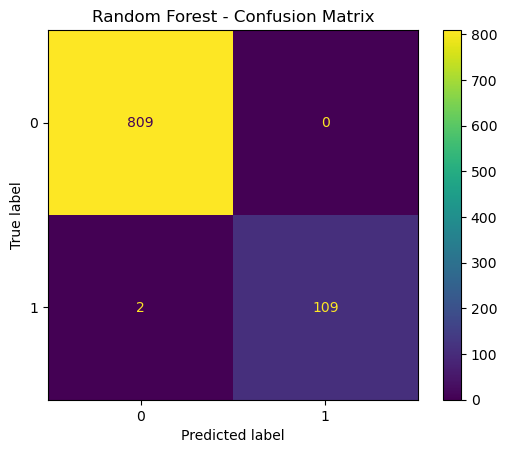

In [13]:
cm_rf = confusion_matrix(y_test, rf_test_pred)
ConfusionMatrixDisplay(confusion_matrix=cm_rf).plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()


# Task 19 – Decision Tree vs Random Forest Comparison

In [14]:
comparison_df = pd.DataFrame([dt_results, rf_results])

comparison_df = comparison_df[[
    'Model',
    'Train Accuracy', 'Test Accuracy',
    'Train Precision', 'Test Precision',
    'Train Recall', 'Test Recall',
    'Train F1', 'Test F1',
    'Train AUC', 'Test AUC'
]]

comparison_df


,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train AUC,Test AUC
0,Decision Tree,1.0,0.969565,1.0,0.880734,1.0,0.864865,1.0,0.872727,1.0,0.924398
1,Random Forest,1.0,0.997826,1.0,1.000000,1.0,0.981982,1.0,0.990909,1.0,0.999944


In [15]:
test_compare = comparison_df[[
    'Model', 'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1', 'Test AUC'
]]

test_compare


,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC
0,Decision Tree,0.969565,0.880734,0.864865,0.872727,0.924398
1,Random Forest,0.997826,1.000000,0.981982,0.990909,0.999944


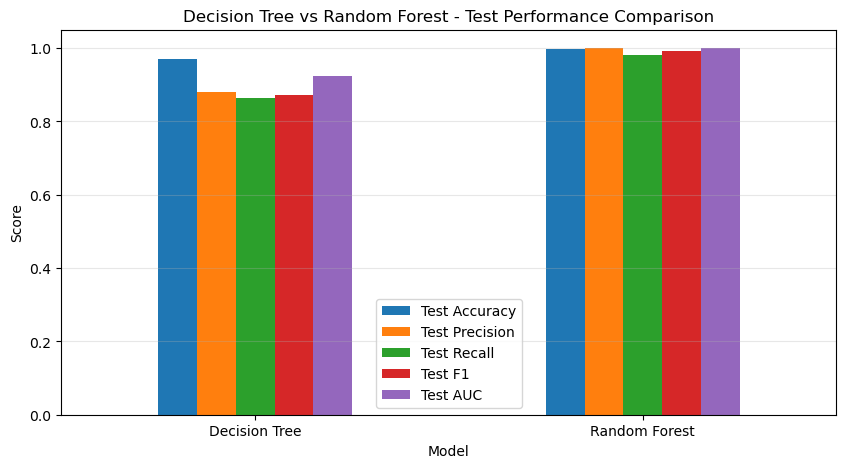

In [16]:
plot_df = test_compare.set_index('Model')
plot_df.plot(kind='bar', figsize=(10,5))
plt.title("Decision Tree vs Random Forest - Test Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()


# Final Interpretation for Part E

## Decision Tree
- Simple and interpretable model
- Can easily **overfit** training data
- If train metrics are much higher than test metrics, generalization is weak

## Random Forest
- Ensemble of multiple decision trees
- Usually performs **better** than a single Decision Tree
- Reduces overfitting and improves stability

## Final Comparison
The better model is the one with:
- higher **test accuracy**
- better **recall** for high-risk customers
- stronger **F1-score**
- higher **AUC-ROC**
- smaller gap between **train and test performance**
